# Investigating SC Data Distribution
So far, we seem to be able to differentiate between lymphoid cells and myeloid cells. However, we also notice a mass bias for our method. Thus, to investigate if this mass bias plays a role or if underrepresentation is skewing results, we'll investigate the structure of the data. Note that even if there is a bias towards total mass, the fact that some cell types have a higher or lower mass on average could still be biologically relevant, especially if this results in reproducible in the original data.

## Imports

In [1]:
### Enabling fast reload ###
%load_ext autoreload
%autoreload 2

In [2]:
### Imports ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
### Directories ###
metadata_save = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT/Metadata'
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

## Loading data

In [4]:
### Loading metadata ###
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
metadata

,cell_name,cell_type
0,arc_pair_7,T cells
1,arc_pair_18,CD4+ T cells
2,arc_pair_31,CD4+ T cells
3,arc_pair_56,T cells
4,arc_pair_57,CD8+ T cells
...,...,...
8058,arc_pair_736107,T cells
8059,arc_pair_736132,CD8+ T cells
8060,arc_pair_736144,CD8+ T cells
8061,arc_pair_736230,Monocytes


In [5]:
### Loading mass ###
max_mass_norm = pd.read_csv(f"{metadata_save}/1mb_95_maxnorm_total_mass.csv", index_col=0, names=['cell_name', 'total_mass'], header=0)
max_mass_norm

,cell_name,total_mass
0,arc_pair_707432,22.329502
1,arc_pair_261242,35.919775
2,arc_pair_505368,118.361873
3,arc_pair_735113,13.679993
4,arc_pair_563444,9.499326
...,...,...
8676,arc_pair_283680,13.986788
8677,arc_pair_686346,10.555565
8678,arc_pair_447578,10.000115
8679,arc_pair_237773,85.876293


Interesting note is that the metadata file seemingly does not include all datasets

In [6]:
### Merging datasets ###
cells_types_mass = metadata.copy()
cells_types_mass = cells_types_mass.merge(max_mass_norm, on='cell_name')
cells_types_mass.to_csv(f"{metadata_save}/1mb_95_maxnorm_total_mass_celltypes.csv")
cells_types_mass

,cell_name,cell_type,total_mass
0,arc_pair_7,T cells,24.035465
1,arc_pair_18,CD4+ T cells,13.497184
2,arc_pair_31,CD4+ T cells,16.177841
3,arc_pair_56,T cells,11.600458
4,arc_pair_57,CD8+ T cells,14.965568
...,...,...,...
8058,arc_pair_736107,T cells,13.664406
8059,arc_pair_736132,CD8+ T cells,7.776261
8060,arc_pair_736144,CD8+ T cells,7.787857
8061,arc_pair_736230,Monocytes,17.368914


## Visualizing

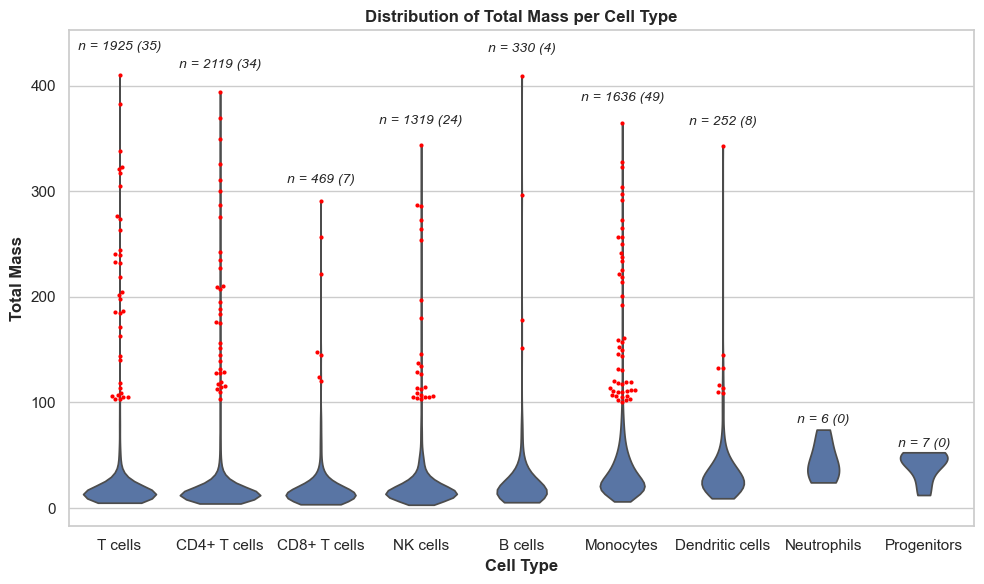

In [16]:
### Violin + swarm plots ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Threshold for outliers
thres = 100
outliers = cells_types_mass[cells_types_mass['total_mass'] > thres]

# Plots
    # Violin plot
ax = sns.violinplot(
    data=cells_types_mass,
    x="cell_type",
    y="total_mass",
    inner=None,  
    cut=0
)
ax.set_ybound(lower=0)

    # Outliers
sns.swarmplot(
    data=outliers,
    x="cell_type",
    y="total_mass",
    color="red",
    size=3,
    dodge=False,
    ax=ax
)

# Add cell count annotations
counts = cells_types_mass["cell_type"].value_counts()
outlier_counts = (
    outliers["cell_type"]
    .value_counts()
    .reindex(counts.index, fill_value=0)
)


# Y position above max mass
y_max = cells_types_mass.groupby("cell_type")["total_mass"].max()

    # Adding extra space to prevent overlap with title
y_min, y_max_plot = ax.get_ylim()
ax.set_ylim(y_min, y_max_plot * 1.05)

for i, cell_type in enumerate(ax.get_xticklabels()):
    ct = cell_type.get_text()
    ax.text(
        i,
        y_max[ct] * 1.05,
        f"n = {counts[ct]} ({outlier_counts[ct]})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle='italic'
    )

# Labels
ax.set_xlabel("Cell Type", fontweight='bold')
ax.set_ylabel("Total Mass", fontweight='bold')
ax.set_title("Distribution of Total Mass per Cell Type", fontweight='bold')

plt.tight_layout()

- Overall, the data seems to be pretty comparable.
    - Myeloid cells to show a little more mass on average, but not too much.
- Neutrophils and progenitors indeed include a very small amount of cells, explaining their consistent placement.
- Monocytes and DCs being clustered with the lymphoid cells is still a little strange, warrants investigation into outliers.